100002453

'Consumer Cyclical'


# Step 0  — Setup and Sector Filter

Load the dataset and apply the same cleaning seen in class: keep only active companies, 
remove ETFs and funds. Then filter to your assigned sector.

Let's start importing the uncleaned dataset

In [1]:
import pandas as pd
import numpy as np

from matplotlib.ticker import FuncFormatter

df_raw= pd.read_csv('/Users/chris/Desktop/ChristianBDA2026/data/symbol_info_3-25.csv')
print("Dataset shape:", df_raw.shape)
df_raw.head()
# Now just clean our dataset, removing ETFs and Funds

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,...,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,...,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,...,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,...,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,...,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


let's remove all the unmissed data

In [2]:
summary = pd.DataFrame({

    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100)
})
summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


Clean teh dataset

In [3]:
df = df_raw.copy()

df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

df["market_cap_b"]       = df["market_cap"]      / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"]          = df["total_revenue"]    / 1e9
df["net_income_b"]       = df["net_income"]       / 1e9
df["free_cashflow_b"]    = df["free_cashflow"]    / 1e9

df["profit_margin_pct"]  = df["profit_margins"]   * 100
df["revenue_growth_pct"] = df["revenue_growth"]   * 100
df["earnings_growth_pct"]= df["earnings_growth"]  * 100
df["return_on_assets_pct"]= df["return_on_assets"]* 100
df["return_on_equity_pct"]= df["return_on_equity"]* 100

df["dividend_yield_pct"] = df["dividend_yield"]
df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment universe:", df.shape)

Cleaned investment universe: (993, 49)


Filter to Consumer Cyclical sector

In [4]:

df_Consumer_C = df[df['sector'] == 'Consumer Cyclical']
print(df_Consumer_C)



    symbol                 company_name             sector  \
3     AMZN             Amazon.com, Inc.  Consumer Cyclical   
11    TSLA                  Tesla, Inc.  Consumer Cyclical   
25      HD       Home Depot, Inc. (The)  Consumer Cyclical   
39     MCD       McDonald's Corporation  Consumer Cyclical   
50     PDD            PDD Holdings Inc.  Consumer Cyclical   
..     ...                          ...                ...   
985     AN             AutoNation, Inc.  Consumer Cyclical   
991   BBWI      Bath & Body Works, Inc.  Consumer Cyclical   
993    EAT  Brinker International, Inc.  Consumer Cyclical   
997    VFC             V.F. Corporation  Consumer Cyclical   
999    BWA              BorgWarner Inc.  Consumer Cyclical   

                     industry     market_cap  enterprise_value  current_price  \
3             Internet Retail  2079374704640     2133579530240     196.210007   
11         Auto Manufacturers   799980716032      777646112768     248.710007   
25    Home I

# Step 1  — Market Capitalization Distribution 
Plot a histogram of market_cap for your sector. Add two vertical lines: one for the mean, one for the median. Both must be annotated with their value. 

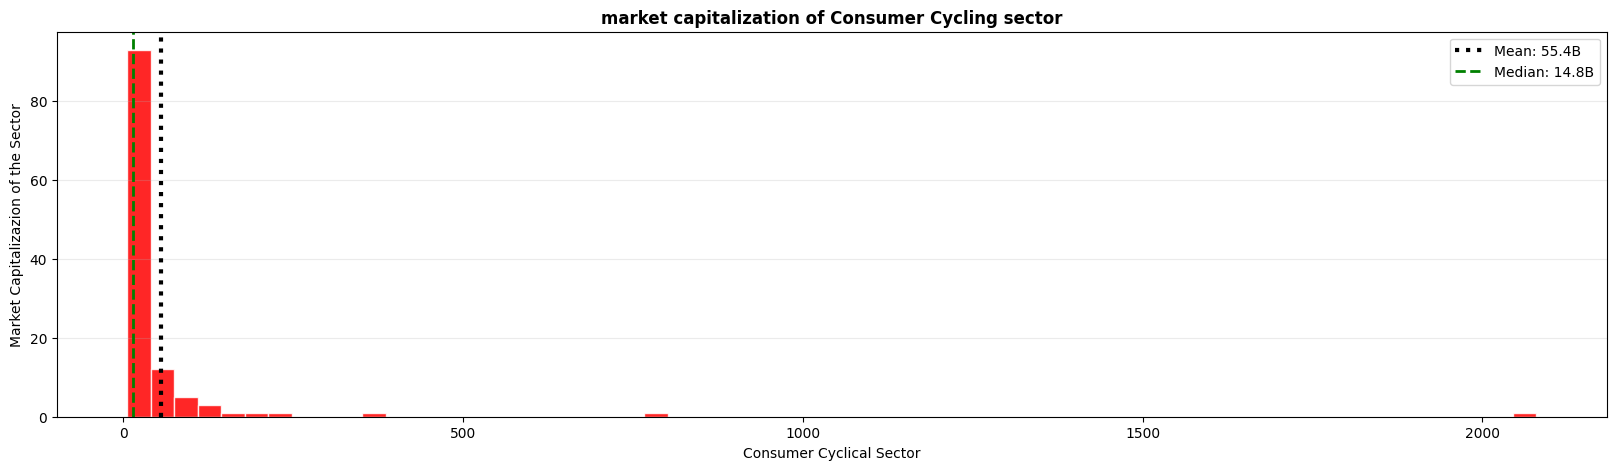

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

market_cap_C = df_Consumer_C['market_cap_b'].dropna()

fig, ax = plt.subplots(figsize=(20, 5))

ax.hist(
    market_cap_C,
    bins = 60,
    color = 'red',
    edgecolor = 'white',
    alpha = 0.85
)

Mean_value = market_cap_C.mean()
Median_value = market_cap_C.median()

ax.axvline(Mean_value, color = 'black', linestyle = ':', linewidth = 3, label=f"Mean: {Mean_value:,.1f}B")
ax.axvline(Median_value, color = 'green', linestyle = '--', linewidth = 2, label= f"Median: {Median_value:,.1f}B")

ax.set_title("market capitalization of Consumer Cycling sector")
plt.xlabel("Consumer Cyclical Sector")
plt.ylabel("Market Capitalizazion of the Sector")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.show()

# Step 2  — Outlier Detection Boxplot

Plot a boxplot of market_cap. If needed, remove outliers. 
Use the cleaned dataset from this point forward.

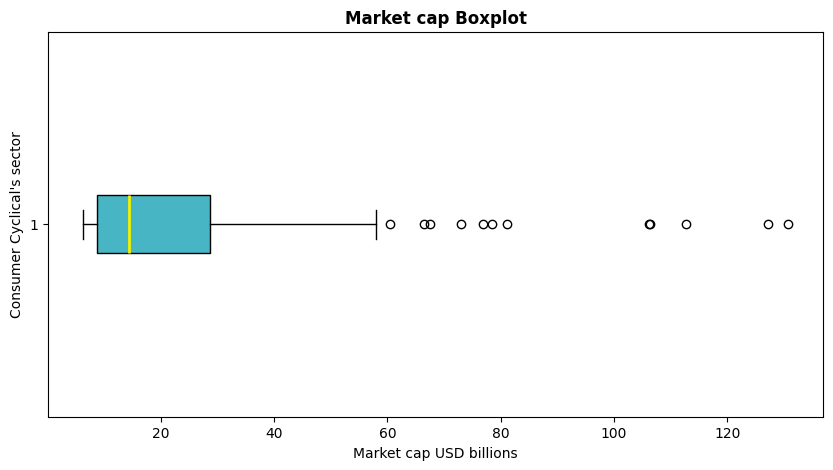

In [6]:
df_cc = df_Consumer_C[df_Consumer_C['market_cap_b']<=150].copy()
# firstly, the boxplot show 6 big market cap companies above 150B, that unshaped the boxplot
# So I filtered them out to focus on the Consumer Cycling sector

fig, ax = plt.subplots(figsize=(10,5))


ax.boxplot(
    df_cc['market_cap_b'],
    vert = False,
    patch_artist= True,
    medianprops={"color": "#f4f100", "linewidth": 2},
    boxprops = {"facecolor": "#48b5c4", }
)


ax.set_title("Market cap Boxplot")
plt.ylabel("Consumer Cyclical's sector")
plt.xlabel("Market cap USD billions")




plt.show()

# Step 3  — Industry Comparison: Four Metrics

Create a single figure with 4 subplots. Each subplot is a horizontal bar chart showing the mean value per industry for one of the following metrics: 
•  market_cap 
•  total_revenue 
•  profit_margins 
•  beta

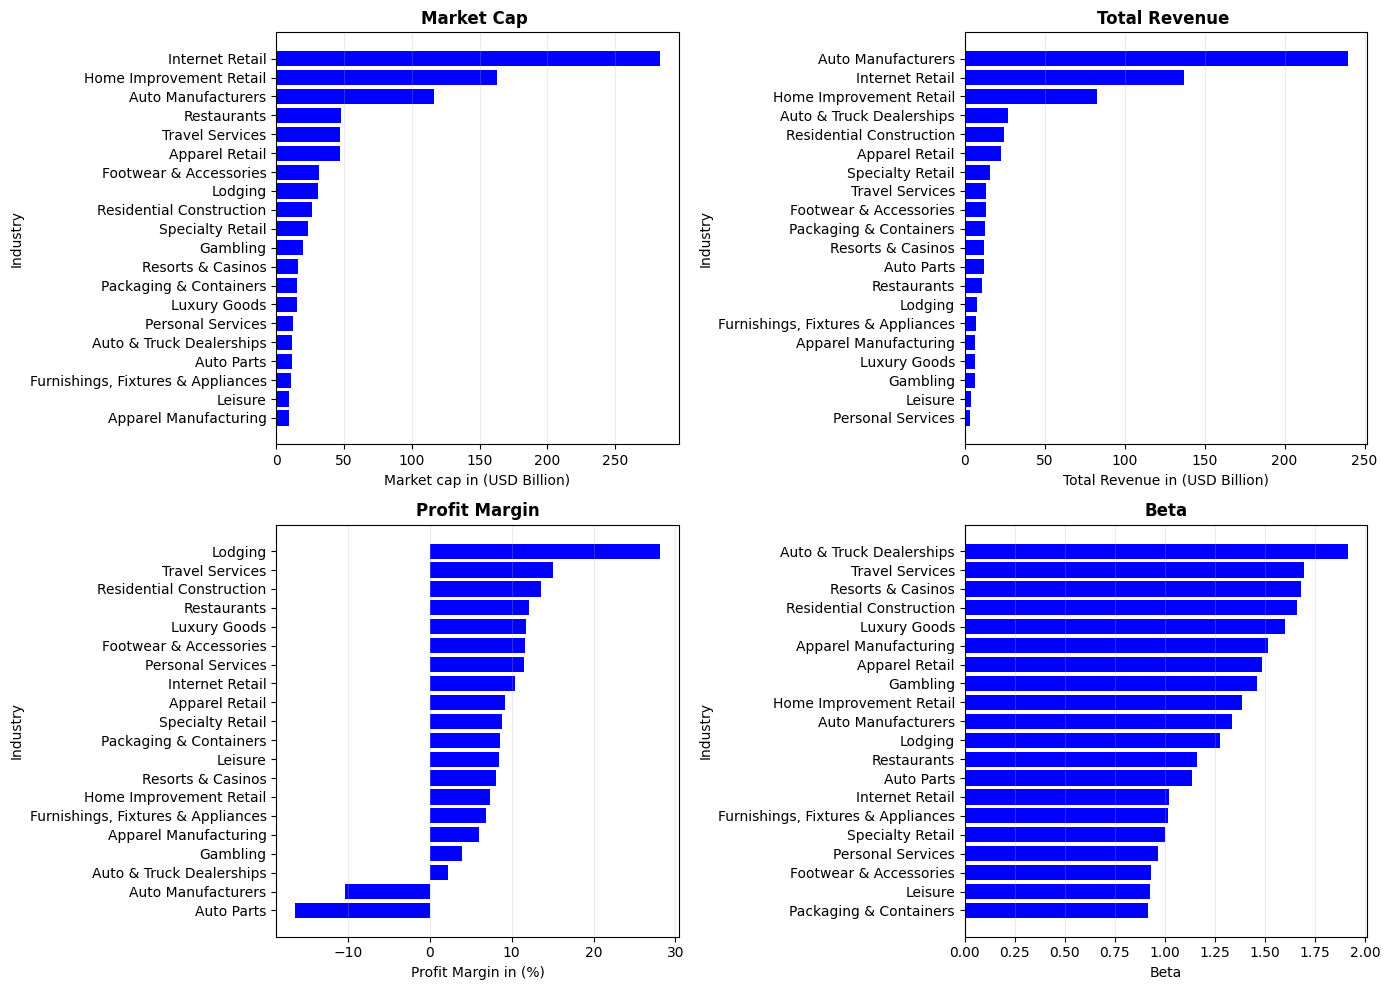

In [7]:
df_industry = df_Consumer_C.copy()
df_industry['industry_clean'] = df_industry["industry"].fillna('Unknown')




market_cap_industry = (
    df_industry
    .groupby('industry_clean')['market_cap_b']
    .mean()
    .sort_values(ascending = True)

 )

total_revenue_industry = (
    df_industry
    .groupby('industry_clean')['revenue_b']
    .mean()
    .sort_values(ascending=True)

)

profit_margins_industry = (
    df_industry
    .groupby('industry_clean')['profit_margin_pct']
    .mean()
    .sort_values(ascending = True)

)

beta_industry = (
    df_industry
    .groupby('industry_clean')['beta']
    .mean()
    .sort_values(ascending = True)

)

fig, axes = plt.subplots( # I put axes because  the 4 graphs
    nrows = 2,
    ncols= 2,
    figsize=(14,10)
)

ax_market_cap = axes[0, 0]
ax_total_revenue = axes [0, 1]
ax_profit_margin = axes [1, 0]
ax_beta = axes [1, 1]

### first barth char

ax_market_cap.barh(

    market_cap_industry.index,
    market_cap_industry.values,
    color = 'Blue'
)

ax_market_cap.set_title("Market Cap ")
ax_market_cap.set_ylabel("Industry")
ax_market_cap.set_xlabel("Market cap in (USD Billion)")
ax_market_cap.grid(axis = "x", alpha = 0.25)



#### second barh chart


ax_total_revenue.barh(

    total_revenue_industry.index,
    total_revenue_industry.values,
    color = 'Blue'
)

ax_total_revenue.set_title("Total Revenue ")
ax_total_revenue.set_ylabel("Industry")
ax_total_revenue.set_xlabel("Total Revenue in (USD Billion)")
ax_total_revenue.grid(axis = "x", alpha = 0.25)



#### third barh chart


ax_profit_margin.barh(

    profit_margins_industry.index,
    profit_margins_industry.values,
    color = 'Blue'
)


ax_profit_margin.set_title("Profit Margin")
ax_profit_margin.set_ylabel("Industry")
ax_profit_margin.set_xlabel("Profit Margin in (%)")
ax_profit_margin.grid(axis = "x", alpha = 0.25)

#### quarth barh chart


ax_beta.barh(

    beta_industry.index,
    beta_industry.values,
    color = 'Blue'
)

ax_beta.set_title("Beta")
ax_beta.set_ylabel("Industry")
ax_beta.set_xlabel("Beta")
ax_beta.grid(axis = "x", alpha = 0.25)


plt.tight_layout()
plt.show()

Create 4 boxplots, one per metric (market_cap, total_revenue, profit_margins, beta). 
Each boxplot must show the full distribution broken down by industry, not just the mean.

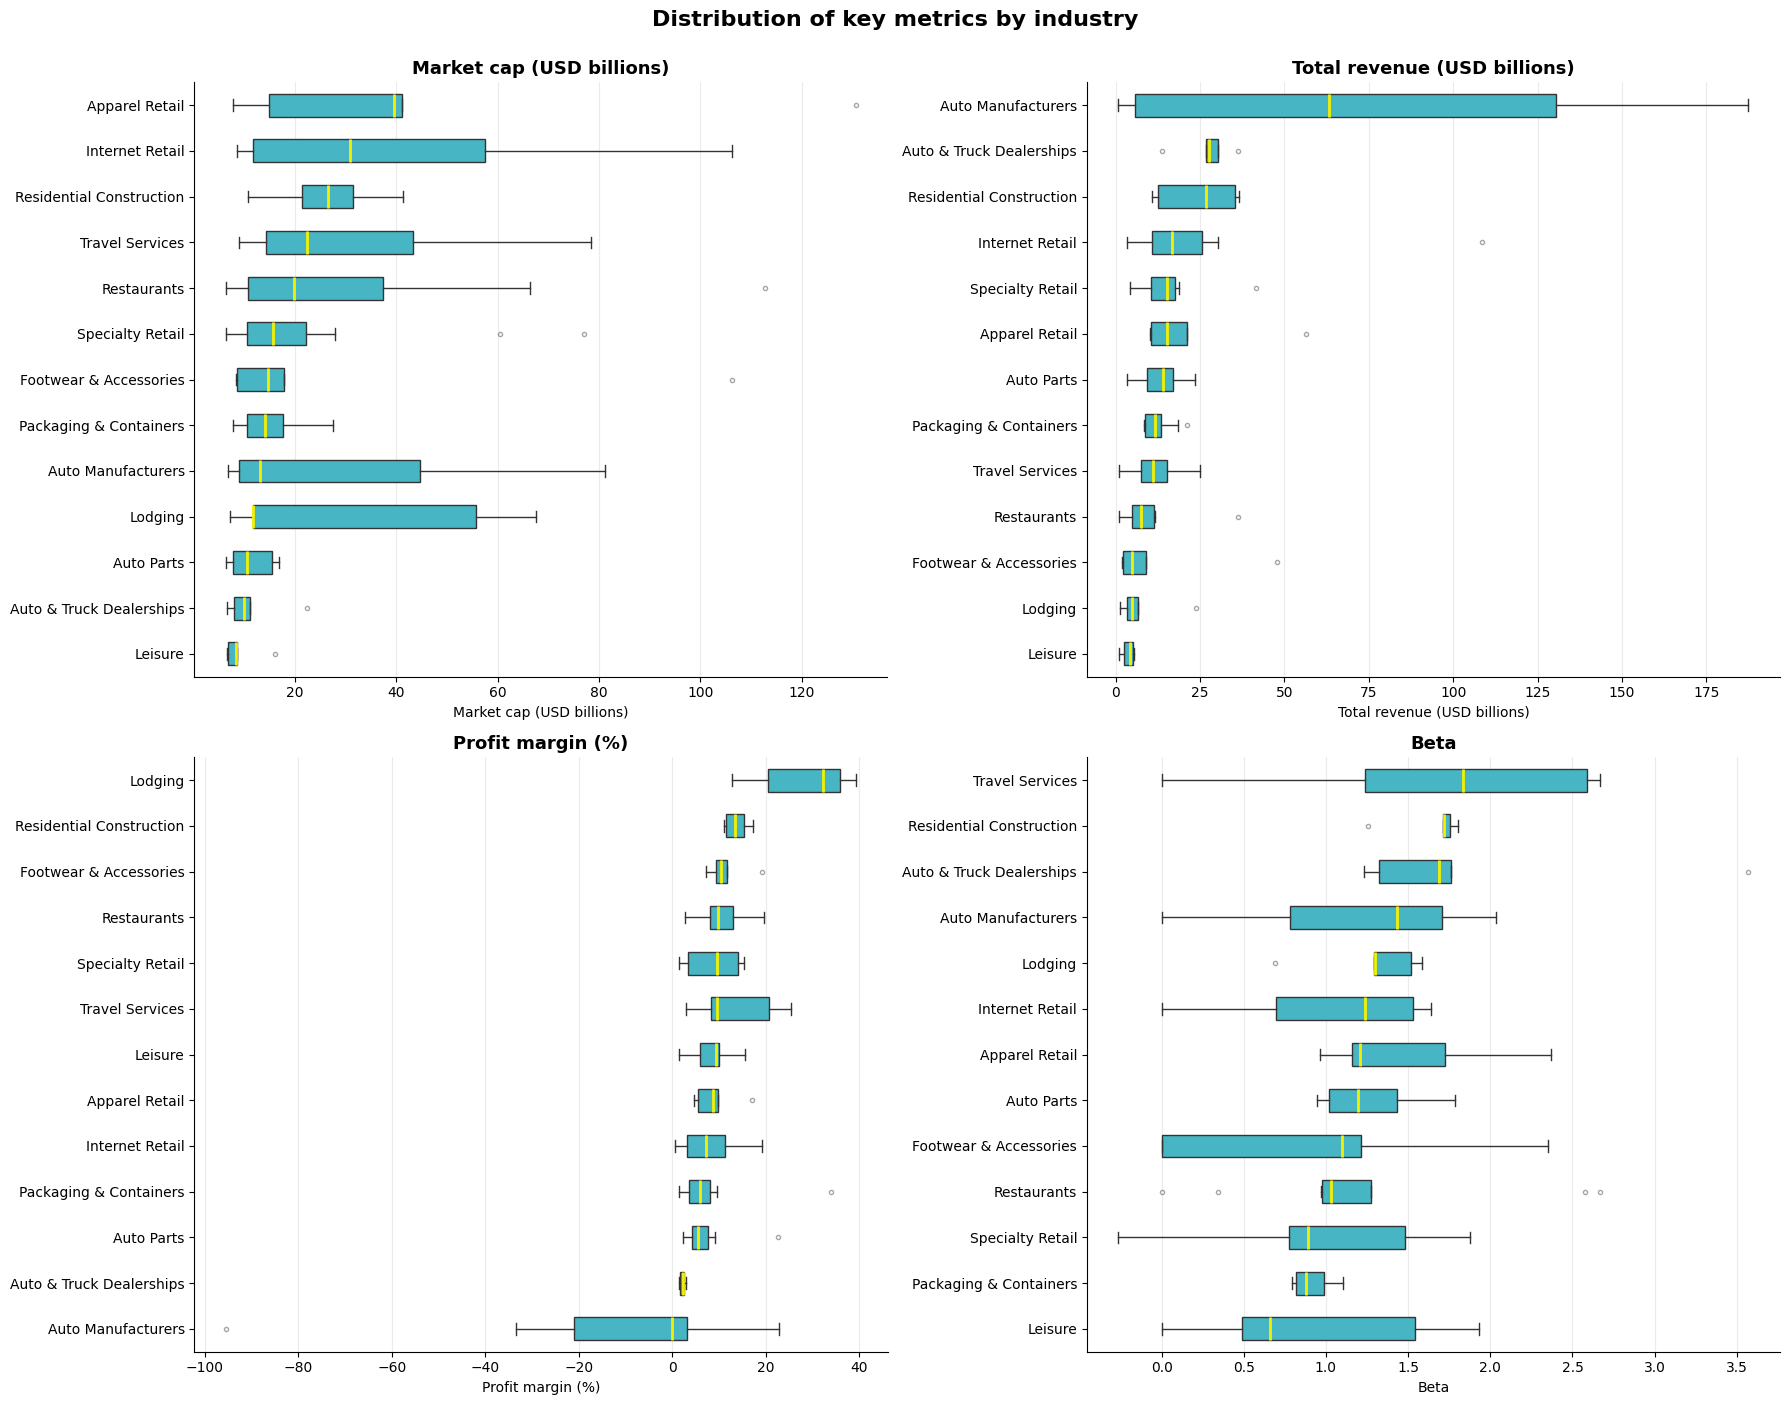

In [ ]:
# Dataset preparation

# Drop rows with NaN in the columns we need
box_df = df_cc.dropna(
    subset=['industry', 'market_cap_b', 'revenue_b', 'profit_margin_pct', 'beta']
).copy()

# Filter outliers to keep the scales readable
# (mega-caps and huge revenues were crushing the other boxes)
box_df = box_df[
    (box_df['market_cap_b'] <= 1000) &
    (box_df['revenue_b'] <= 500) &
    (box_df['profit_margin_pct'].between(-100, 80))
]

# Keep only industries with at least 5 companies
industry_counts = box_df['industry'].value_counts()
big_industries = industry_counts[industry_counts >= 5].index
box_df = box_df[box_df['industry'].isin(big_industries)]


# === The 4 metrics ===

metrics = [
    ('market_cap_b',      'Market cap (USD billions)'),
    ('revenue_b',         'Total revenue (USD billions)'),
    ('profit_margin_pct', 'Profit margin (%)'),
    ('beta',              'Beta'),
]


# === 2x2 grid ===

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics):

    # Sort industries by median of the current metric
    industry_order = (
        box_df.groupby('industry')[col]
        .median()
        .sort_values(ascending=True)
        .index
    )

    # List of arrays: one per industry
    data = [
        box_df.loc[box_df['industry'] == ind, col].values
        for ind in industry_order
    ]

    # Boxplot
    ax.boxplot(
        data,
        tick_labels=industry_order,
        vert=False,
        patch_artist=True,
        boxprops={"facecolor": "#48b5c4", "edgecolor": "#333333"},
        medianprops={"color": "#f4f100", "linewidth": 2},
        whiskerprops={"color": "#333333"},
        capprops={"color": "#333333"},
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
    )

    ax.set_title(label, fontsize=13)
    ax.set_xlabel(label)
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Distribution of key metrics by industry",
             fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

# Step 5: Focus Industry Selection

Based on Steps 3 and 4, select 3 or 4 industries to carry forward. Filter the dataset to 
those industries only. 
In a comment or markdown cell, justify your choice for each industry you keep and each one 
you drop. The justification must reference specific values or patterns you observed in the 
charts, not general opinions about the industry. 
 


In [9]:
top_4_industry = ['Lodging', 'Restaurants', 'Residential Construction', 'Travel Services']

df_cc = df_cc[df_cc['industry'].isin(top_4_industry)].copy()

print(f"All Business: {len(df_cc)}")
print("\nBusiness for Industry:")
print(df_cc['industry'].value_counts())

All Business: 29

Business for Industry:
industry
Restaurants                 11
Travel Services              7
Residential Construction     6
Lodging                      5
Name: count, dtype: int64


## Industry selection: 4 industries from Consumer Cyclical

Selection based on patterns observed in Step 3 and Step 4.

### Industries selected

**Lodging** — It has the highest profit margin in the sector: median 30% (Step 3) and 
mean 28% (Step 4), both confirming good profitability. Beta is around 
1.2, suggesting consistent moderate volatility. 
Low revenue (5B mean) is the trade-off, but margins compensate.

**Restaurants** — Most defensive profile of the sector. beta is 1.1, Mean profit margin 
11% confirmed by a narrow boxplot. Mean market cap 50B (driven by Mcdonald's, Starbucks) places it among the larger industries by scale.

**Residential Construction** — Mean profit margin 13% and mean revenue 
25B (Step 4), with mediana confirming consistency. 
High beta 1.75 mean, but tight dispersion in Step 3, so the cyclical 
exposure is predictable rather than chaotic.

**Travel Services** — Highest beta in the sector after Auto & Truck 
Dealerships (mean 1.7 in Step 4, boxplot median 2.0 with range between 1.2 and 2.5). 
Profit margin mean 14%

### Industries dropped

**Auto Manufacturers**: Mean revenue 240B, the highest in the sector 
(Step 4), but mean profit margin is -12%, the second worst. Boxplot confirms: 
median margin -15%, outliers below -90%. Highest revenue does not translate 
into profitability.

**Auto Parts**: Worst mean profit margin in Step 4 (-15%), with the 
boxplot showing a mediana near 5%, meaning a few large losses drag down 
the average. Inconsistent profitability profile.

**Auto & Truck Dealerships**: Highest mean beta in Step 4 (1.9) combined 
with very low mean profit margin (2%). Thin-margin business with maximum 
volatility, worst risk/return ratio of the sector.

**Internet Retail**: Mean market cap 280B (Step 4) is deceptive: the 
Step 3 boxplot reveals a median of only 30B, meaning Amazon alone inflates 
the mean. The industry is heterogeneous, also visible in the wide beta IQR 
(0-1.6) in the boxplot. Hard to draw conclusions about a "typical" company.

**Home Improvement Retail**: Strong mean market cap (170B, Step 4) but 
mean profit margin only 8%. Too few companies (3) to appear in Step 3 


**Apparel Retail, Footwear & Accessories, Packaging & Containers, Specialty 
Retail**: Mean profit margins in the 8-10% range (Step 4) and unremarkable 
market cap (15-50B). The Step 3 boxplots show no standout pattern — these 
are "middle of the pack" industries that don't add a distinctive profile to 
the selection.

**Leisure, Personal Services, Luxury Goods, Furnishings/Apparel 
Manufacturing, Resorts & Casinos, Gambling** — Smallest scale in Step 4 
(mean market cap below 20B, mean revenue below 10B). Most have too few 
companies to be analyzed reliably in Step 3 (filtered out by the n≥5 rule).

# Step 6: Bubble Chart 

Using the filtered dataset from Step 5, create a bubble chart. You decide: 
•  what goes on the x-axis 
•  what goes on the y-axis 
•  what determines bubble size 
•  what determines bubble color 
 
Document these four choices in a comment before the code, and explain what each encoding 
is meant to reveal. 
Divide the chart into 4 quadrants. Each quadrant represents a combination of the two axis 
values: for example, if you chose beta on the x-axis and market_cap on the y-axis, the four 
quadrants will represent companies that are simultaneously high or low on each dimension 
(high beta and high cap, low beta and high cap, and so on). Label each quadrant with the 
combination it represents..

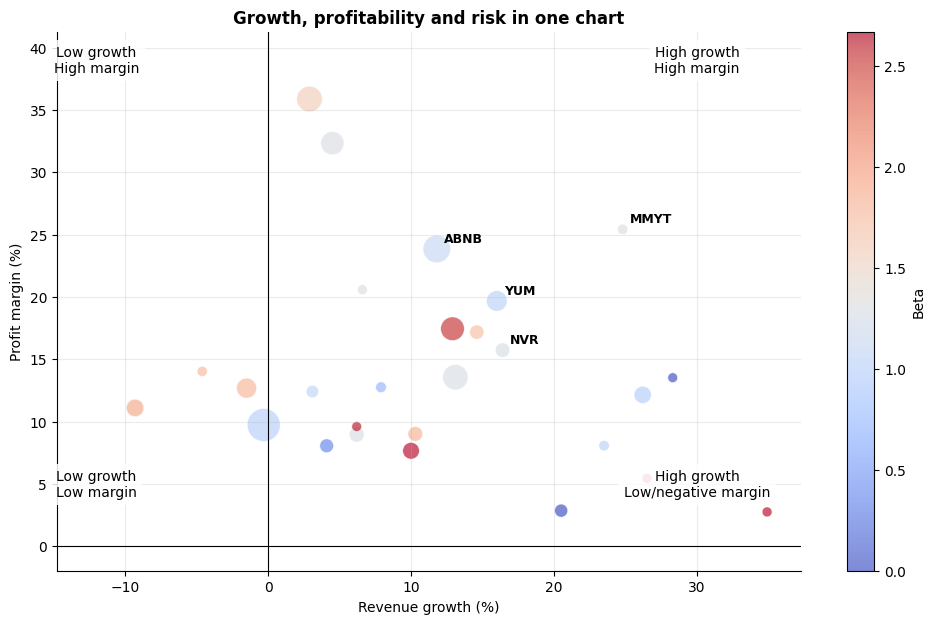

In [ ]:
# Encoding choices:
#
# - X axis: revenue_growth_pct
#   Top-line momentum. Reveals whether each company is expanding
#
# - Y axis: profit_margin_pct
#   Bottom-line profitability. Reveals which companies are
#
# - Bubble size: market_cap_b
#   Company scale. Reveals which firms are dominant by size, so
#
# - Bubble color: beta (coolwarm)
#   Reveals how market sensitivity distributes:
#     blue = beta < 1 (defensive)
#     white = beta ≈ 1 (market-like)
#     red = beta > 1.5 (cyclical, amplifies market moves)



growth_df = df_cc[
    (df_cc["revenue_growth_pct"].between(-50, 100)) &
    (df_cc["profit_margin_pct"].between(-50, 80)) &
    (df_cc["beta"].between(0, 3))
].dropna(subset=["revenue_growth_pct", "profit_margin_pct", "beta", "market_cap_b"]).copy()

fig, ax = plt.subplots(figsize=(12, 7))

sizes = (growth_df["market_cap_b"] * 5).clip(lower=50, upper=800)

points = ax.scatter(
    growth_df["revenue_growth_pct"],
    growth_df["profit_margin_pct"],
    s=sizes,
    c=growth_df["beta"],
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)

# Reference lines create four quadrants
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

# Adding the  quadrant labels
#low growth, high margin
ax.text(-12, 38, "Low growth\nHigh margin",          fontsize=10, ha="center",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))


#high growth, high margin
ax.text(30, 38, "High growth\nHigh margin",          fontsize=10, ha="center",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))


#low growth, low margin
ax.text(-12, 4, "Low growth\nLow margin",            fontsize=10, ha="center",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))


#high growth, low/negative margin
ax.text(30, 4, "High growth\nLow/negative margin",   fontsize=10, ha="center",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

# Annotate attractive candidates: positive growth, positive margin, beta below 1.5
candidates_for_labels = growth_df[
    (growth_df["revenue_growth_pct"] > 10) &
    (growth_df["profit_margin_pct"] > 15) &
    (growth_df["beta"] < 1.5)
].nlargest(10, "market_cap_b")

for _, row in candidates_for_labels.iterrows():
    ax.annotate(
        row["symbol"],
        (row["revenue_growth_pct"], row["profit_margin_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

ax.set_title("Growth, profitability and risk in one chart")
ax.set_xlabel("Revenue growth (%)")
ax.set_ylabel("Profit margin (%)")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Beta")

plt.show()

# Step 7  — Zoom into One Quadrant 

Choose one quadrant from Step 6 and justify your choice in a comment. Filter to the 
companies in that quadrant. If there are more than 10, keep the top 10 by a dimention you 
prefer. 
Use the yfinance example seen in class to download the last 3 months of daily closing 
prices. Normalize all series to 1 on the first available trading day and plot them on a single 
chart with a legend identifying each company. 
In your comments, reflect on what you observe in the price chart in relation to the 
current geopolitical situation, in particular the tensions in the Strait of Hormuz.  
Were the companies in this quadrant visibly affected?  
Do you see a sharp drop, a gradual decline, or no significant impact?  
Is there any sign of recovery

Top-right business: 23

After filtering top 10 based on market cap: 10
    symbol  market_cap_b
149   ABNB     78.382023
179    MAR     67.501310
184    CMG     66.411364
204    RCL     57.994609
212    HLT     55.796679
266    YUM     44.067443
358    QSR     30.715212
377    CCL     28.660158
435    DRI     23.421198
451   EXPE     22.303820


[*********************100%***********************]  10 of 10 completed


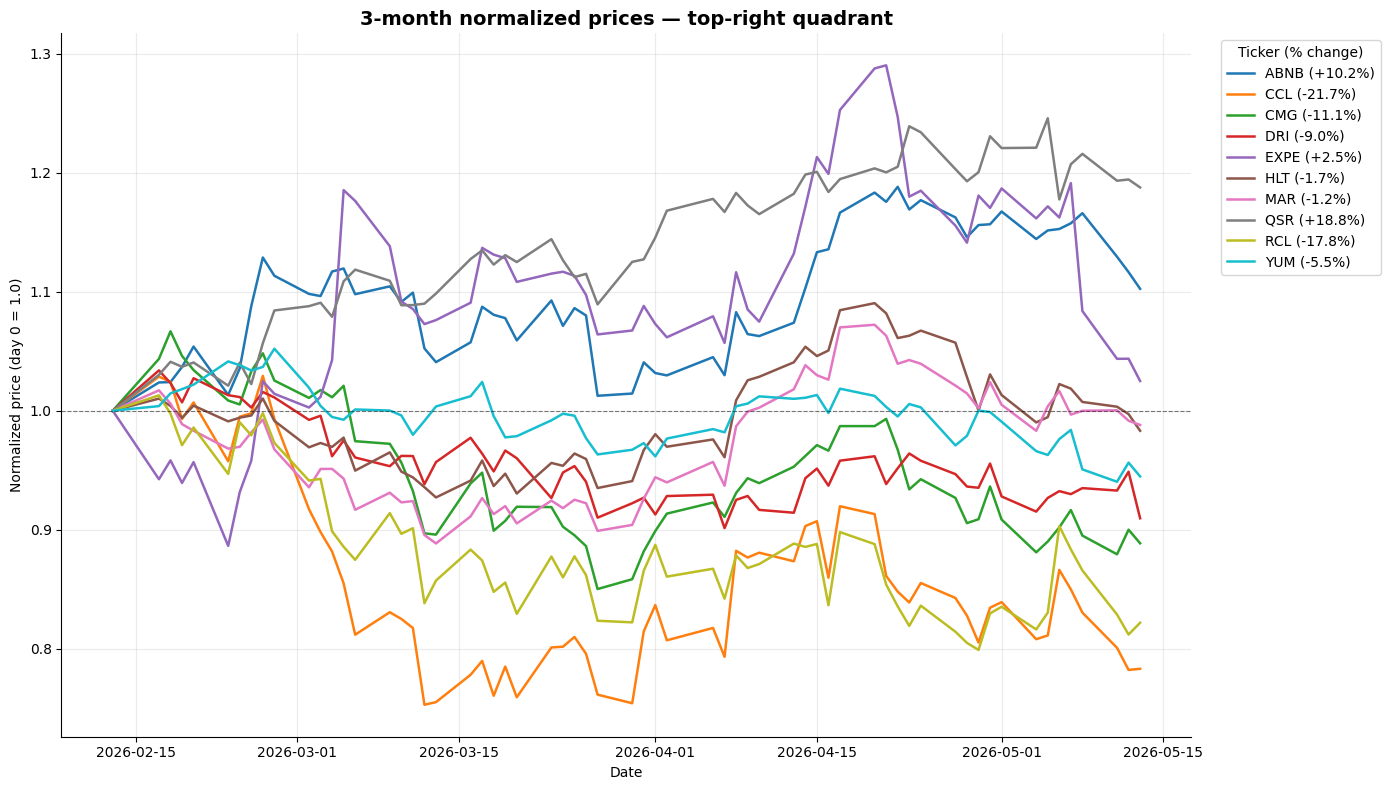

In [ ]:
# Quadrant choice: TOP-RIGHT (high growth + high margin).
# This is the most attractive quadrant of Step 6: companies that are
# growing and already profitable. 
#
# - Top-right: ABNB, MMYT, YUM, NVR, growing companies 
# with strong margins. Color shows they all stay at beta ≤ 1.5, so the 
# growth doesn't come with excessive market risk.
#
#The other quadrants either represent
# stagnant businesses (left) or unprofitable growth (bottom-right).
# Top-10 picked by market cap, as a measure of dominance.



top_right = growth_df[

    (growth_df['revenue_growth_pct'] > 0) &
    (growth_df['profit_margin_pct'] > 0)
].copy()

print(f"Top-right business: {len(top_right)}")

# Now I will just keep only the firt 10 business

if len(top_right) > 10:
    top_right = top_right.nlargest(10, "market_cap_b")
    print(f"\nAfter filtering top 10 based on market cap: {len(top_right)}")
    print(top_right[["symbol", "market_cap_b"]]
)
    
import yfinance as yf

# Build the ticker list
tickers = top_right['symbol'].tolist()

# Download daily closing prices for the last 30 days

data = yf.download(tickers,  period = "3mo", interval = "1d", auto_adjust=True )
closing_prices = data["Close"]

# Drop tickers that failed to download
closing_prices = closing_prices.dropna(axis=1, how="all")

# Normalize: divide every series by its first available value
# so each series starts at 1.0 on day 0
normalized_prices = closing_prices / closing_prices.iloc[0]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))


palette = plt.cm.tab10(np.linspace(0, 1, len(normalized_prices.columns)))

for color, ticker in zip(palette, normalized_prices.columns):
    series = normalized_prices[ticker]
    final_value = series.iloc[-1]
    pct_change = (final_value - 1) * 100

    ax.plot(series.index, series.values, color=color, linewidth=1.8,
            label=f"{ticker} ({pct_change:+.1f}%)")


# Horizontal reference line at 1.0 it's the starting point
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_title("3-month normalized prices — top-right quadrant",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price (day 0 = 1.0)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Ticker (% change)")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



#The Strait of Hormuz handles 20% of global oil, which causes 
# tensions and a rapid increase in fuel costs that will 
# inevitably hit travel demand.
#
# The 10 stocks split into three groups:
#   - Cruise lines (CCL -21%, RCL -17%) dropped sharply in early
#     March doubly exposed (fuel + Middle East routes)
#   - The hotels remaing flat (HLT, MAR 0%), online travel up (ABNB +10%,
#     EXPE +2%) low fuel sensitivity, may benefit from 
#     substitution from cancelled cruises
#   - The restaurants spread widely (QSR +20%, CMG -10%) driven by
#     company specific news, not geopolitics
#
# Were these companies visibly affected?
# Yes, but only fuel-heavy / route-dependent models like cruises.
# Hotels, travel platforms and restaurants were not.
#
# harp drop, gradual decline, or no impact?
# Sharp drop for cruises 2-3 weeks in early March. The rest of
# the panel did not show the same pattern.
#
# Sign of recovery?
# Cruises stopped declining but trade sideways at lows no a clear
# recovery. Instead Hotels are flat. ABNB, EXPE, QSR moved above their
# starting points, but for reasons unrelated to Hormuz.

# Step 8  — Compare with an Excluded Quadrant

Pick one of the three remaining quadrants from Step 6. 
Apply the same procedure as Step 7: take the top 10 companies by the same dimention, 
download the last 3 months of prices, normalize, and plot on a single chart. 
In your comments, compare the behavior of this group with the one in Step 7.  
Did these companies react differently to the same geopolitical context?  
Were they more resilient, more exposed, or did they follow a similar pattern?
Comment on whether the quadrant logic, i.e. the combination of metrics you used to define 
it, helps explain any difference (if any) in behavior. 

Low Margin Business: 6
    symbol                  industry  revenue_growth_pct  profit_margin_pct  \
100   SBUX               Restaurants                -0.3           9.729999   
283    DHI  Residential Construction                -1.5          12.685001   
354    LEN  Residential Construction                -9.3          11.096000   
355  LEN-B  Residential Construction                -9.3          11.096000   
690      H                   Lodging               -12.4          39.320001   
739    TOL  Residential Construction                -4.6          14.029999   

     market_cap_b   beta  
100    112.774947  0.985  
283     41.335607  1.806  
354     31.519355  1.710  
355     31.519302  1.710  
690     11.782204  1.516  
739     10.656611  1.763  


[*********************100%***********************]  6 of 6 completed


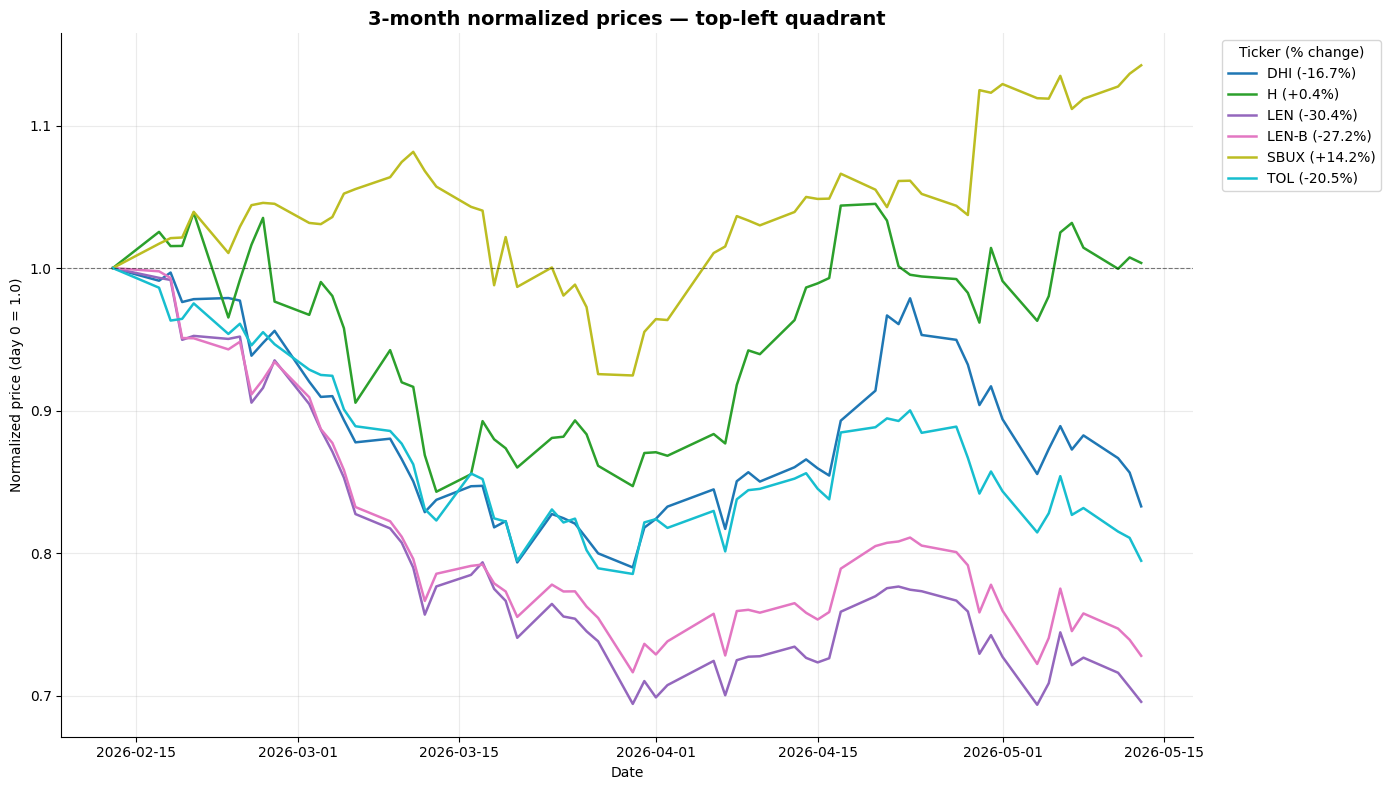

In [ ]:
top_left = growth_df[

    (growth_df['revenue_growth_pct'] < 0) &
    (growth_df['profit_margin_pct'] > 0)
].copy()

print(f"Low Margin Business: {len(top_left)}")

if len(top_left) > 10:
    top_left = top_left.nlargest(10, "market_cap_b")

print(top_left[["symbol", "industry", "revenue_growth_pct",
                "profit_margin_pct", "market_cap_b", "beta"]])

tickers = top_left['symbol'].tolist()

data = yf.download(tickers, period = '3mo', interval = '1d', auto_adjust=True)
closing_prices = data['Close']
closing_prices = closing_prices.dropna(axis=1, how = 'all')

normalized_prices = closing_prices / closing_prices.iloc[0]

#Chart

fig, ax = plt.subplots(figsize=(14, 8))


palette = plt.cm.tab10(np.linspace(0, 1, len(normalized_prices.columns)))

for color, ticker in zip(palette, normalized_prices.columns):
    series = normalized_prices[ticker]
    final_value = series.iloc[-1]
    pct_change = (final_value - 1) * 100

    ax.plot(series.index, series.values, color=color, linewidth=1.8,
            label=f"{ticker} ({pct_change:+.1f}%)")

ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_title("3-month normalized prices — top-left quadrant",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized price (day 0 = 1.0)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Ticker (% change)")
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# Comment:
#
# Same structural pattern in both quadrants: 4 stocks drop sharply
# during the same month of March , 2 hold or gain. What differs is the
# industry driving the drop:
#
#   - Top-right (Step 7): cruise lines collapse (CCL -21%, RCL -17%)
#   - Top-left  (Step 8): homebuilders collapse (LEN -30%, TOL -20%, DHI -17%)
#
# Top-left was more exposed: worst case -30% vs -21%, only SBUX (+14%)
# ended positive vs three names in top-right. The high-margin profile
# did not protect these stocks.
#
# The quadrant logic only partially explains this. The real driver is
# the industry mix in each quadrant, top-right caught travel names
# maybe is linked to Hormuz due to fuel costs and routes. 
# Top-left caught homebuilders, sensitive to US interest rates, unrelated to
# Hormuz. The simultaneous drop in two unrelated industries suggests
# a broader macro/risk-off event, not just a geopolitical shock.
#
# The quadrants work as a screening tool, but industry
# analysis matters more for short-term price behavior.

# FINAL SUMMARY

### Sector overview: size, profitability, and risk

I analyzed the **Consumer Cyclical** sector, which contains 119 active
companies after filtering the raw dataset. 
The sector is highly heterogeneous in size:
- **market cap** ranges from under 1B to over 200B, with a small number of
'Outlier' companies' names (AMZN, TSLA) dominate the mean but do not represent the typical company; the median market cap is below 20B. 

- **Profitability** is also dispersed: while most companies operate at positive margins (5-15% median by industry), a few sub-industries notably Auto Manufacturers and
Auto Parts show negative or quite zero margins. 

- **Risk**, measured by beta, is structurally above 1.0 for most sub-industries, consistent with a sector defined by cyclical demand. The highest betas above 1.7 are for "Auto & Truck Dealerships" industries, like "Travel Services" and "Residential Construction".

### Industry selection rationale

After I kept **Lodging, Restaurants, Residential Construction and Travel Services**: Those industries are composed of 29 companies total. 
Each industry was justified on the boxplots and bar charts.
- **Lodging** stood out for the highest median profit margin near 40% with moderate beta. 
- **Restaurants** offered the most stability with a consistent margin 10% and beta 1.0.
- **Residential Construction** combined solid margins 13% with
revenue 25B median; 
- Travel Services was kept as a high-risk/high-return position beta 2.0. 

I excluded auto manufacturers because of the negative median margin despite the highest
revenue, and also Auto & Truck Dealerships low margins and highest beta.

### Bubble chart insights

The bubble chart I chose has axes (revenue growth, profit margin, sized by market cap,
colored by beta) showed that the graph is divided in four quadrants; 

**top-right quadrant** (high growth and high margin) collected the most
attractive candidates: ABNB, MMYT, YUM, NVR, all with beta ≤ 1.5. Instead, 
Homebuilders clustered to the left (low growth) despite strong margins.

### Price behavior and geopolitical reflection

Over the last 3 months:
- the **top-right** group split into three buckets:
travel platforms like (ABNB +10%, EXPE +2%) and QSR (+20%) had positive performance. 
hotels stayed flat, and cruise lines collapsed (CCL -21%, RCL -17%). 

- The **top-left** group showed an much deeper drawdown, driven by homebuilders (LEN -30%, LEN-B -27%, TOL -20%, DHI -17%), with only SBUX (+14%) gaining meaningfully. 
As visualised in the previous graph, the simultaneous drop of cruise lines and homebuilders during
the same March window suggests the dominant driver was broad macro
risk-off, not specifically Strait of Hormuz tensions. 
Hormuz likely amplified the cruise's business weakness (fuel cost, Middle East routes),
but cannot explain the homebuilder collapse as a consequence of material lack. So, the quadrant logic served well as a screening tool but did not predict short-term price behaviour: Industry composition
within each quadrant mattered more than the quadrant itself.